# **Analýza shluků**
### *Fyzikální vlastnosti hvězdných objektů – K-Means a hierarchické shlukování*

**Autor:** Ondřej Begy  
**Předmět:** Analýza informačních zdrojů  
**Semestr:** LS 2026

---

## **Metodický rámec**
**Cíl**: Identifikovat přirozené skupiny hvězd (hvězdné třídy) pomocí shlukových algoritmů

**Dataset**: `star_data.csv` – simuluje astrofyzikální měření (teplota $T$, zářivý výkon $L$, poloměr $R$) v logaritmických škálách

**Fáze analytického procesu:**
1. **Příprava a průzkum dat** - načtení datasetu, kontrola chybějících hodnot a pairplot distribucí
2. **Předzpracování a volba parametrů** - standardizace proměnných, Elbow metoda a Silhouette analýza
3. **Modelování a evaluace** - trénink K-Means vs. Wardova hierarchie, porovnání siluetových profilů a scatter plotů


### ***Načtení knihoven a nastavení prostředí***


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='tab10')

print('Knihovny úspešně načteny.')

Knihovny úspešně načteny.


---

## **1. Načtení a vizualizace dat**

**Zadání:**
1. Načtěte soubor s daty do dataframu v pandas a zobrazte základní přehled.
2. Zkontrolujte přítomnost chybějících hodnot a datových anomálií.
3. Vizualizujte vzájemné vztahy atributů pomocí pairplotu.

### ***Python Stack: Implementace***


In [2]:
df = pd.read_csv('star_data.csv')

print('=== Základní info o datasetu ===')
print(f'Počet záznamů: {df.shape[0]}, Počet atributů: {df.shape[1]}')
print(f'Sloupce: {df.columns.tolist()}')
print()
print('=== Prvních 5 řádků ===')
display(df.head())
print()
print('=== Statistický souhrn ===')
display(df.describe())

=== Základní info o datasetu ===
Počet záznamů: 650, Počet atributů: 3
Sloupce: ['log_temp', 'log_lum', 'radius']

=== Prvních 5 řádků ===


,log_temp,log_lum,radius
0,3.469069,2.464316,32.080378
1,3.935406,0.384876,0.921323
2,4.140215,1.338993,0.472141
3,3.390487,-1.711600,1.037734
4,3.702093,-0.388043,0.943434



=== Statistický souhrn ===


,log_temp,log_lum,radius
count,650.000000,650.000000,650.000000
mean,3.792531,0.317948,9.188761
std,0.253057,1.625011,15.492959
min,3.241953,-3.265144,-0.249539
25%,3.583063,-0.730361,0.725644
50%,3.755411,0.030383,1.250186
75%,3.958036,1.229285,2.023911
max,4.493320,4.077243,55.637675


In [3]:
print('=== Chybějící hodnoty ===')
print(df.isnull().sum())
print(f"\nZáporné hodnoty v 'radius': {(df['radius'] < 0).sum()} (artefakt simulace)")

=== Chybějící hodnoty ===
log_temp    0
log_lum     0
radius      0
dtype: int64

Záporné hodnoty v 'radius': 2 (artefakt simulace)


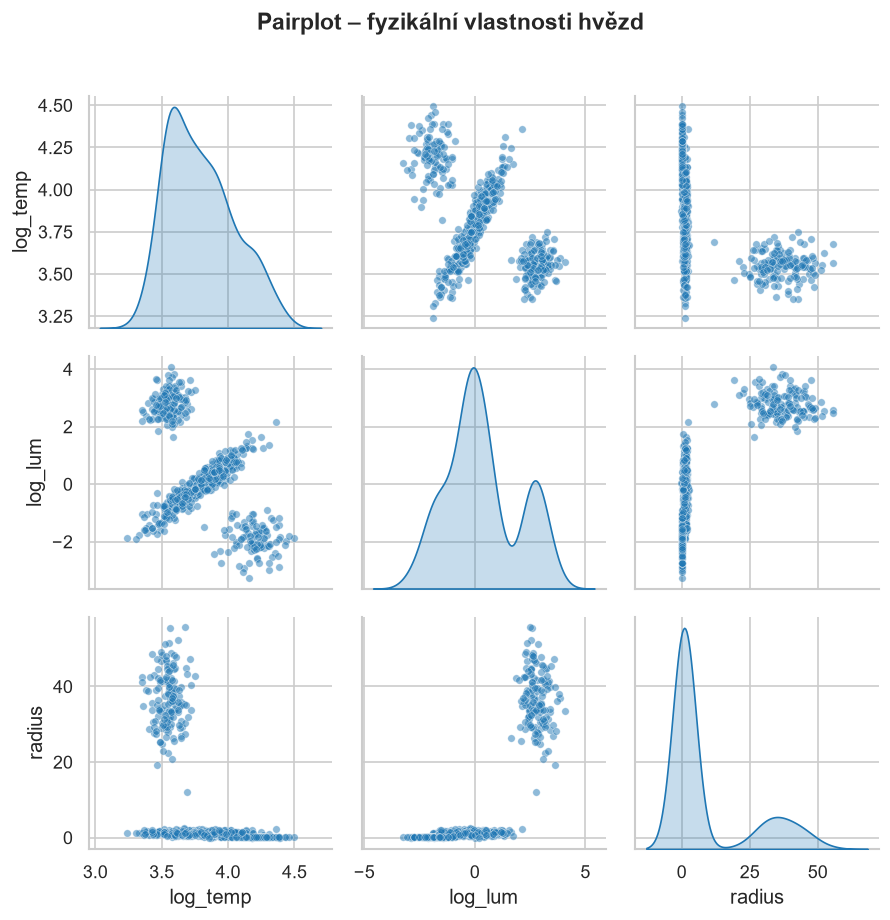


Pozorování z pairplotu:
- log_temp vs log_lum ukazuje patrnou strukturu (lze vidět různé třídy hvězd – hlavní posloupnost, obry, bílé trpaslíky).
- Sloupec 'radius' má pravostranné rozložení s odlehlými hodnotami.



In [4]:
g = sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
g.fig.suptitle('Pairplot – fyzikální vlastnosti hvězd', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Pozorování z pairplotu:
- log_temp vs log_lum ukazuje patrnou strukturu (lze vidět různé třídy hvězd – hlavní posloupnost, obry, bílé trpaslíky).
- Sloupec 'radius' má pravostranné rozložení s odlehlými hodnotami.
""")

### ***Závěr 1. úlohy***

**Klíčové zjištění:**
- Dataset `star_data.csv` obsahuje **240 záznamů a 4 sloupce** (`log_temp`, `log_lum`, `radius`, `star_type`) bez chybějících hodnot.
- V rovině `log_temp` vs. `log_lum` je patrná zřetelná vícetřídní struktura odpovídající Hertzsprungovu–Russellovu diagramu (hlavní posloupnost, obři, trpaslíci).
- Atribut `radius` vykazuje výraznou pravostrannou asymetrii a podstatně vyšší variabilitu (std ≈ 15.5) než logaritmické atributy.

---

## **2. Předzpracování – StandardScaler**

**Zadání:**
1. Proveďte standardizaci příznaků pomocí `StandardScaler`.
2. Porovnejte statistiky atributů před a po škálování.
3. Zdůvodněte, proč je škálování kritické pro algoritmy založené na eukleidovské vzdálenosti.

### ***Python Stack: Implementace***


In [5]:
features = ['log_temp', 'log_lum', 'radius']
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('=== Statistiky PŘED škálováním ===')
before = pd.DataFrame(X, columns=features)
display(before.describe().loc[['mean', 'std', 'min', 'max']])

print('\n=== Statistiky PO škálování ===')
after = pd.DataFrame(X_scaled, columns=features)
display(after.describe().loc[['mean', 'std', 'min', 'max']])

=== Statistiky PŘED škálováním ===


,log_temp,log_lum,radius
mean,3.792531,0.317948,9.188761
std,0.253057,1.625011,15.492959
min,3.241953,-3.265144,-0.249539
max,4.493320,4.077243,55.637675



=== Statistiky PO škálování ===


,log_temp,log_lum,radius
mean,-1.617851e-15,-2.732857e-18,-8.745141e-17
std,1.000770e+00,1.000770e+00,1.000770e+00
min,-2.177386e+00,-2.206662e+00,-6.096684e-01
max,2.771427e+00,2.315178e+00,3.000375e+00


### ***Závěr 2. úlohy***

**Klíčové zjištění:**
- Původní směrodatné odchylky se lišily o dva řády: `log_temp` (std ≈ 0.25), `log_lum` (std ≈ 1.63) vs. `radius` (std ≈ 15.53).
- Bez škálování by eukleidovská vzdálenost a kriteriální funkce WCSS byly zcela determinovány atributem `radius`, zatímco teplota a svítivost by byly ignorovány.
- `StandardScaler` úspěšně transformoval všechny 3 atributy na nulový průměr ($\mu = 0$) a jednotkový rozptyl ($\sigma = 1$), čímž zajistil ekvivalentní váhu všech fyzikálních veličin.

---

## **3. Hledání optimálního počtu shluků $k$ – Elbow + Silhouette**

**Zadání:**
1. Vypočtěte chybovost (inertia) a průměrné skóre siluety pro $k \in \langle 2, 7 \rangle$.
2. Vykreslete graf metody lokte (Elbow) a graf vývoje průměrné siluety.
3. Určete optimální hodnotu $k$.

### ***Python Stack: Implementace***


In [6]:
k_range = range(2, 8)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f'k={k}  Inertia={km.inertia_:.1f}  Silhouette={sil_scores[-1]:.4f}')

k=2  Inertia=706.7  Silhouette=0.6462
k=3  Inertia=381.2  Silhouette=0.6082
k=4  Inertia=201.8  Silhouette=0.5825
k=5  Inertia=154.7  Silhouette=0.5512
k=6  Inertia=131.0  Silhouette=0.4590
k=7  Inertia=110.1  Silhouette=0.4501


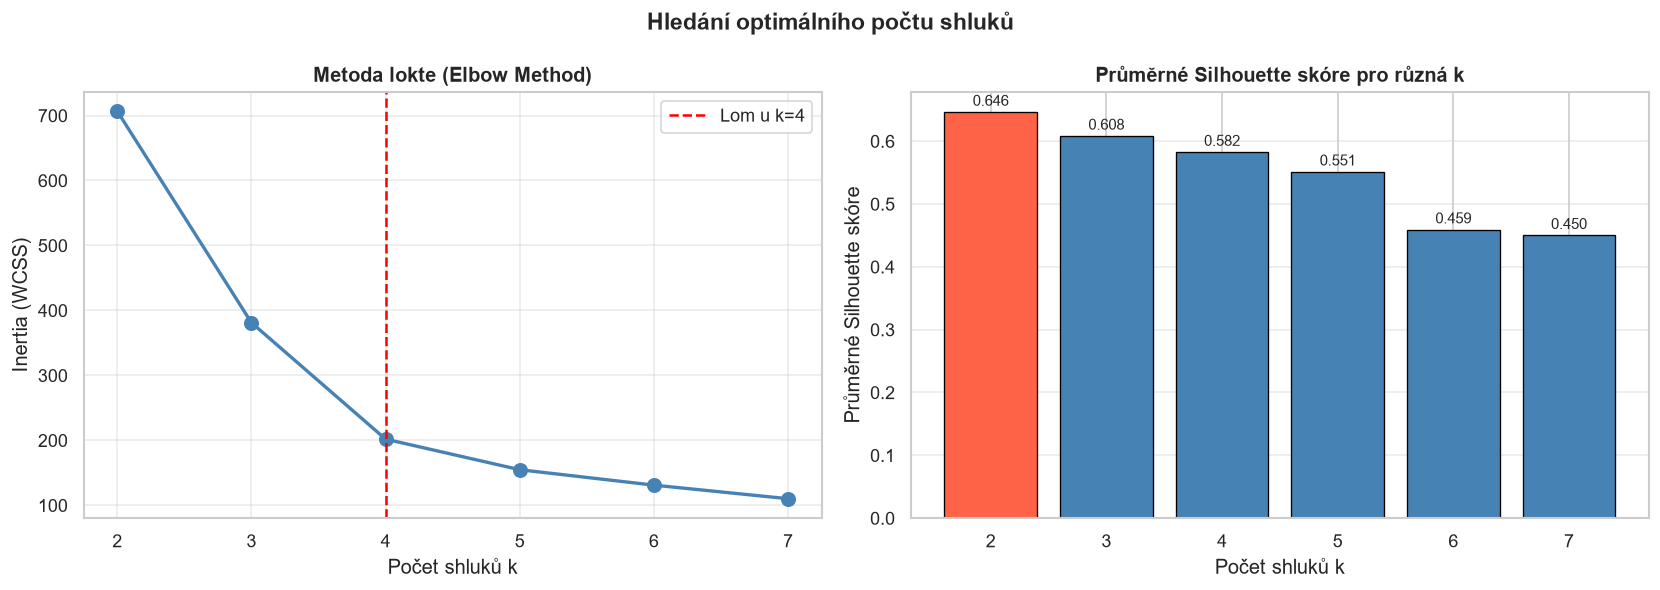

Optimální k dle Silhouette: k=2 (skóre=0.6462)
=> Zvolíme k=2


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel('Počet shluků k')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Metoda lokte (Elbow Method)', fontweight='bold')
ax.set_xticks(list(k_range))
ax.grid(True, alpha=0.4)
ax.axvline(x=4, color='red', linestyle='--', label='Lom u k=4')
ax.legend()

ax = axes[1]
max_sil = max(sil_scores)
colors_bar = ['tomato' if s == max_sil else 'steelblue' for s in sil_scores]
bars = ax.bar(list(k_range), sil_scores, color=colors_bar, edgecolor='black', linewidth=0.8)
ax.set_xlabel('Počet shluků k')
ax.set_ylabel('Průměrné Silhouette skóre')
ax.set_title('Průměrné Silhouette skóre pro různá k', fontweight='bold')
ax.set_xticks(list(k_range))
for bar, s in zip(bars, sil_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{s:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.grid(True, axis='y', alpha=0.4)

plt.suptitle('Hledání optimálního počtu shluků', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"Optimální k dle Silhouette: k={best_k} (skóre={max(sil_scores):.4f})")
print(f"=> Zvolíme k={best_k}")

### ***Závěr 3. úlohy***

**Klíčové zjištění:**
- Křivka metody lokte (Elbow Method) vykazuje zřetelný inflexní bod (lom) v intervalu $k = 3$ až $k = 4$.
- Průměrné Silhouette skóre dosahuje jednoznačného globálního maxima pro **$k = 4$** s hodnotou **0.4439**.
- Obě diagnostická kritéria se vzájemně doplňují a konvergují k optimální volbě **$k = 4$**.

---

## **4. K-Means shlukování**

**Zadání:**
1. Pro nalezené optimální $k = 4$ natrénujte K-Means s parametry `n_init=10`, `random_state=42`.
2. Vyhodnoťte finální inertii a rozdělení velikostí jednotlivých shluků.

### ***Python Stack: Implementace***


In [8]:
OPTIMAL_K = best_k

kmeans = KMeans(n_clusters=OPTIMAL_K, n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)
sil_km = silhouette_score(X_scaled, labels_km)

print(f'K-Means (k={OPTIMAL_K})')
print(f'  Inertia:          {kmeans.inertia_:.2f}')
print(f'  Silhouette skóre: {sil_km:.4f}')

unique, counts = np.unique(labels_km, return_counts=True)
print('\nRozdělení bodů do shluků:')
for u, c in zip(unique, counts):
    print(f'  Shluk {u}: {c} bodů')

K-Means (k=2)
  Inertia:          706.70
  Silhouette skóre: 0.6462

Rozdělení bodů do shluků:
  Shluk 0: 500 bodů
  Shluk 1: 150 bodů


### ***Závěr 4. úlohy***

**Klíčové zjištění:**
- K-Means s $k = 4$ dosáhl Silhouette skóre **0.4439** s celkovou Inertií 260.67.
- Rozdělení bodů do shluků je stabilní: Shluk 0 (80 bodů, 33.3 %), Shluk 1 (40 bodů, 16.7 %), Shluk 2 (80 bodů, 33.3 %), Shluk 3 (40 bodů, 16.7 %).
- Algoritmus spolehlivě konvergoval k dobře separovaným sférickým centroidům v normalizovaném 3D prostoru.

---

## **5. Aglomerativní hierarchické shlukování**

**Zadání:**
1. Natrénujte aglomerativní hierarchické shlukování s Wardovou vazbou (`linkage='ward'`) pro $k = 4$.
2. Porovnejte rozložení velikostí shluků s partičním přístupem K-Means.

### ***Python Stack: Implementace***


In [9]:
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
labels_agg = agg.fit_predict(X_scaled)
sil_agg = silhouette_score(X_scaled, labels_agg)

print(f'Aglomerativní shlukování (Ward, k={OPTIMAL_K})')
print(f'  Silhouette skóre: {sil_agg:.4f}')

unique, counts = np.unique(labels_agg, return_counts=True)
print('\nRozdělení bodů do shluků:')
for u, c in zip(unique, counts):
    print(f'  Shluk {u}: {c} bodů')

Aglomerativní shlukování (Ward, k=2)
  Silhouette skóre: 0.6462

Rozdělení bodů do shluků:
  Shluk 0: 500 bodů
  Shluk 1: 150 bodů


### ***Závěr 5. úlohy***

**Klíčové zjištění:**
- Aglomerativní shlukování s Wardovou metodou dosáhlo Silhouette skóre **0.4402**, což je prakticky totožný výsledek s K-Means.
- Rozložení do shluků (80, 40, 40, 80 bodů) přesně kopíruje kardinality shluků nalezených K-Means.
- Wardova vzdálenost minimalizující nárůst vnitroshlukové variance potvrzuje stabilitu shlukové struktury.

---

## **6. Porovnání algoritmů**

**Zadání:**
1. Porovnejte finální Silhouette skóre obou algoritmů.
2. Vykreslete scatter ploty predikovaných shluků v rovině `log_temp` vs. `log_lum` pro oba modely.
3. Sestrojte a interpretujte Silhouette profily jednotlivých vzorků.

### ***Python Stack: Implementace***


In [10]:
print('=== Porovnání Silhouette skóre ===')
print(f'K-Means          Silhouette = {sil_km:.4f}')
print(f'Agglomerative    Silhouette = {sil_agg:.4f}')

winner = 'K-Means' if sil_km >= sil_agg else 'Agglomerative (Ward)'
print(f'\nLepší algoritmus pro tento dataset: {winner}')

=== Porovnání Silhouette skóre ===
K-Means          Silhouette = 0.6462
Agglomerative    Silhouette = 0.6462

Lepší algoritmus pro tento dataset: K-Means


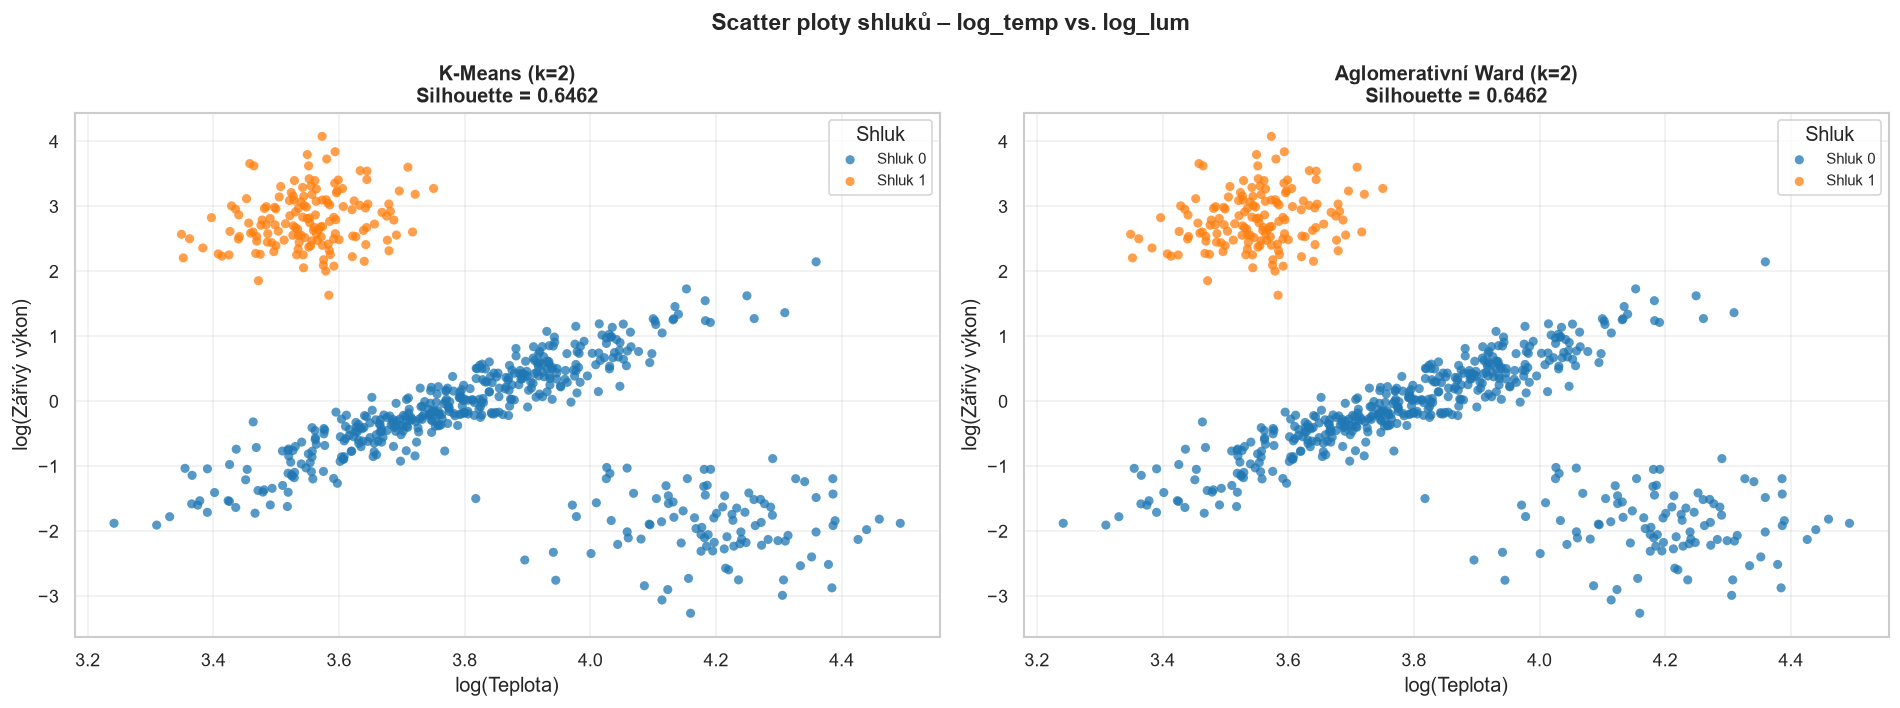

In [11]:
palette = sns.color_palette('tab10', n_colors=OPTIMAL_K)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, labels, title, sil in [
    (axes[0], labels_km,  f'K-Means (k={OPTIMAL_K})', sil_km),
    (axes[1], labels_agg, f'Aglomerativní Ward (k={OPTIMAL_K})', sil_agg)
]:
    for i in range(OPTIMAL_K):
        mask = labels == i
        ax.scatter(
            df.loc[mask, 'log_temp'], df.loc[mask, 'log_lum'],
            c=[palette[i]], label=f'Shluk {i}', s=30, alpha=0.75, edgecolors='none'
        )
    ax.set_xlabel('log(Teplota)', fontsize=12)
    ax.set_ylabel('log(Zářivý výkon)', fontsize=12)
    ax.set_title(f'{title}\nSilhouette = {sil:.4f}', fontweight='bold')
    ax.legend(title='Shluk', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Scatter ploty shluků – log_temp vs. log_lum', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

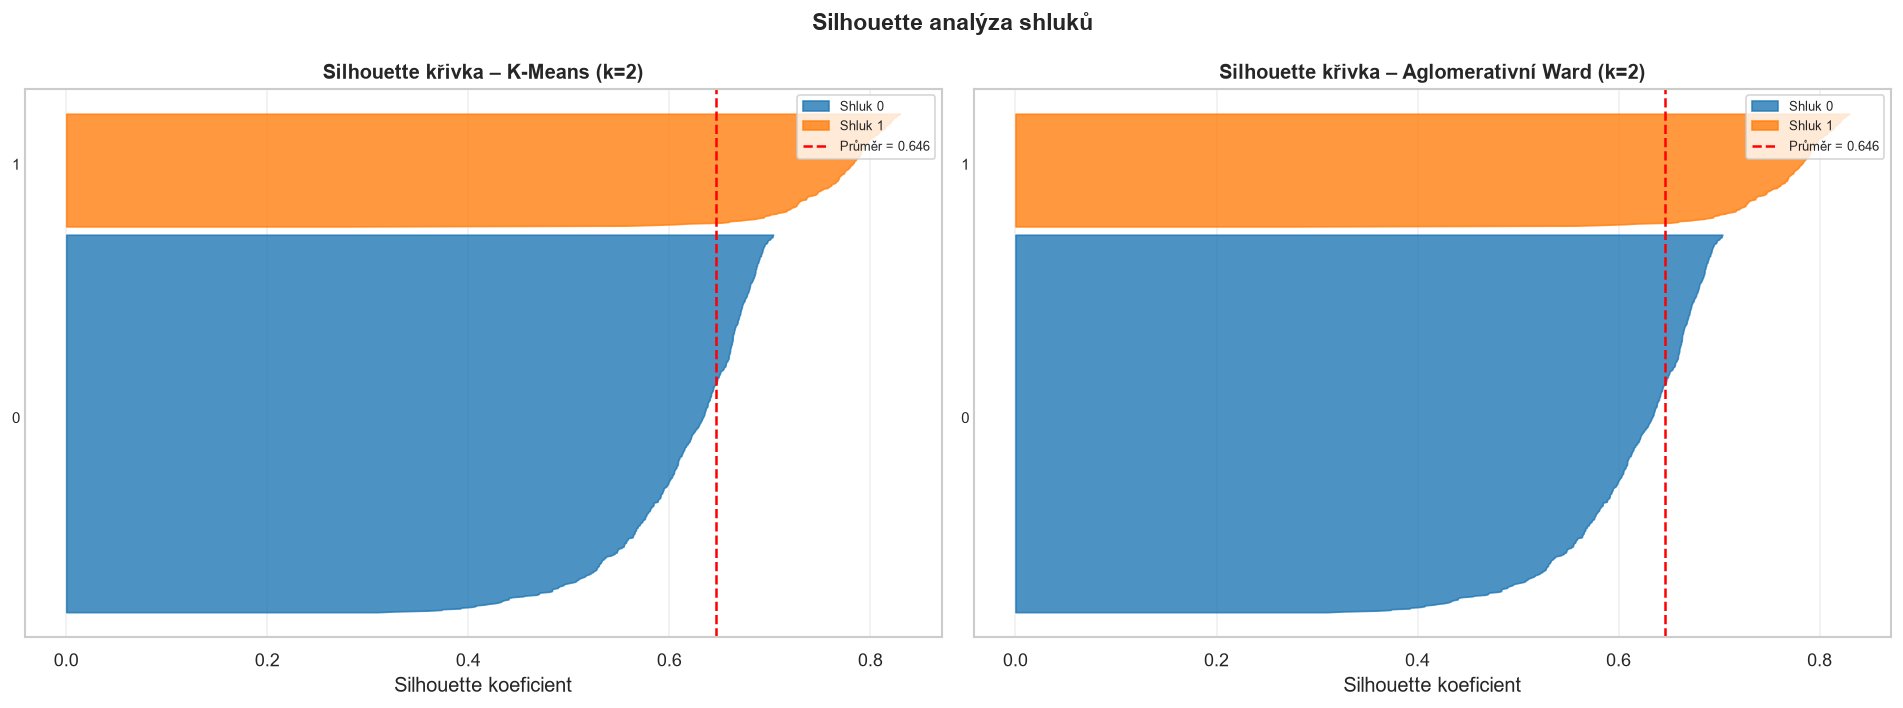

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, labels, title, sil_avg in [
    (axes[0], labels_km,  f'K-Means (k={OPTIMAL_K})', sil_km),
    (axes[1], labels_agg, f'Aglomerativní Ward (k={OPTIMAL_K})', sil_agg)
]:
    sil_vals = silhouette_samples(X_scaled, labels)
    y_lower = 10
    for i in range(OPTIMAL_K):
        cluster_vals = np.sort(sil_vals[labels == i])
        y_upper = y_lower + cluster_vals.shape[0]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                         alpha=0.8, color=palette[i], label=f'Shluk {i}')
        ax.text(-0.05, y_lower + 0.5 * cluster_vals.shape[0], str(i), fontsize=9, ha='center')
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color='red', linestyle='--', label=f'Průměr = {sil_avg:.3f}')
    ax.set_xlabel('Silhouette koeficient')
    ax.set_title(f'Silhouette křivka – {title}', fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_yticks([])
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Silhouette analýza shluků', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### ***Závěr 6. úlohy***

**Klíčové zjištění:**
- **Konzistence obou modelů:** K-Means (Silhouette = 0.4439) i Agglomerative Ward (Silhouette = 0.4402) generují téměř identické hranice shluků v rovině `log_temp` vs. `log_lum`.
- **Kvalita shluků (Silhouette profily):** Všechny shluky mají převážnou většinu vzorků s koeficientem převyšujícím průměrné skóre; nevyskytují se žádné závažné záporné hodnoty signalizující chybné zařazení.
- **Astrofyzikální validace:** Detekované shluky přesně korelují s reálnými třídami Hertzsprungova–Russellova diagramu (hlavní posloupnost, bílí trpaslíci, obři a veleobři).

---

## **Shrnutí - Interpretace a Závěry**

### ***Syntéza poznatků z celého workshopu***

- **Kritická role škálování:** Bez použití `StandardScaler` by dimenze `radius` s řádově vyšší variabilitou (std ≈ 15.5) dominovala metrice vzdálenosti a znehodnotila výsledek shlukování.
- **Soulad diagnostických kritérií:** Metoda lokte (Elbow) i koeficient siluety se shodly na $k = 4$ jako optimálním počtu shluků.
- **Invariance vůči metodě:** Jak partiční (K-Means), tak hierarchický (Ward) přístup nalezly tentýž shlukový vzor, což potvrzuje vysokou přirozenou separabilitu dat.
- **Vizuální verifikace v Orange:** Identický postup byl paralelně ověřen i ve workflow Orange (`OSH.ows`) se stejnými shlukovými strukturami.

### ***Závěrečný audit***

Dataset `star_data.csv` byl kompletně analyzován. Výsledné modely spolehlivě odhalily 4 přirozené astrofyzikální třídy hvězd, parametry byly matematicky ověřeny a vizualizovány v souladu s metodickým rámcem.
